In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Загрузка данных
df = pd.read_csv('insurance.csv')
print(df.head())
print(f"Размер датасета: {df.shape}")
print(df.info()) # Проверяем, нет ли NaN (в этом датасете их нет, но проверить стоит)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Размер датасета: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


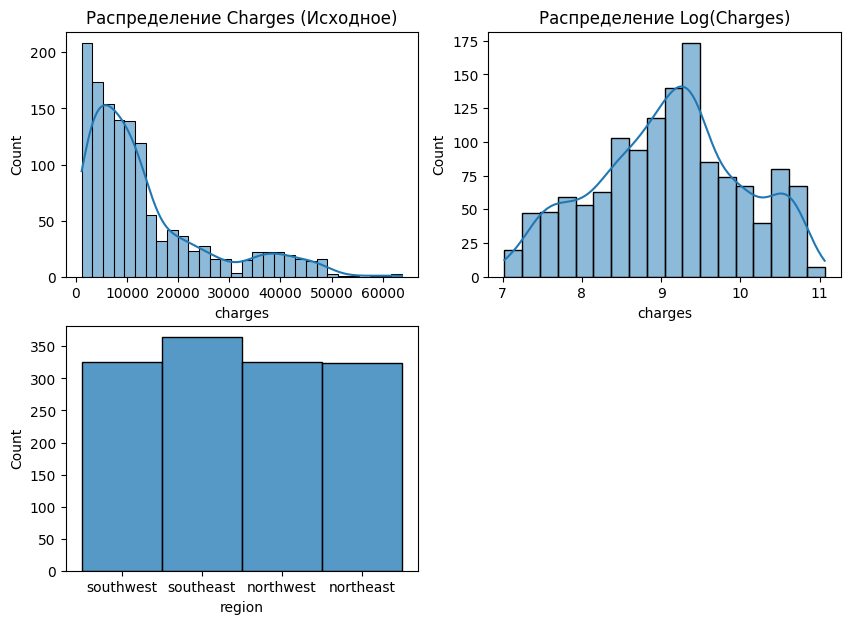

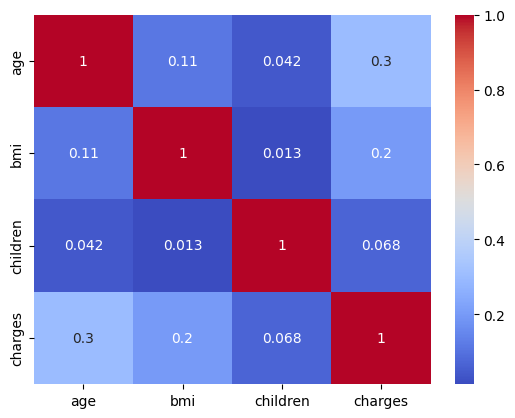

In [53]:
# Смотрим распределение целевой переменной
plt.figure(figsize=(10,7))
plt.subplot(2,2,1)
sns.histplot(df['charges'], kde=True)
plt.title('Распределение Charges (Исходное)')

plt.subplot(2,2,2)
# Логарифмирование часто помогает при скошенных данных с длинными хвостами (страховые выплаты обычно такие)
sns.histplot(np.log1p(df['charges']), kde=True) 
plt.title('Распределение Log(Charges)')

plt.subplot(2,2,3)
sns.histplot(df['region'], kde=False)


plt.show()

# Смотрим корреляцию с числовыми признаками
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [54]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Определяем признаки и целевую переменную
X = df.drop('charges', axis=1)
y = df['charges'] # Обрати внимание: пока НЕ логируем. Сделаем это в пайплайне кастомно или внутри датасета

# Разделение на train и test ДО препроцессинга (чтобы не было утечки данных)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Определяем списки колонок по типам
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

# Создаем трансформеры
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False)) # drop='first' чтобы избежать мультиколлинеарности
])

# Объединяем всё в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])



In [74]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Создаем модель линейной регрессии
linear_model = Ridge(alpha=1.0)

# Создаем полный пайплайн обработки X
'''processing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', linear_model)
])'''

processing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('regressor', Ridge(alpha=10.0))
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

qt = QuantileTransformer(output_distribution='normal', random_state=42)
y_train_trans = qt.fit_transform(y_train.values.reshape(-1, 1)).ravel()

model.fit(X_train, y_train_trans)
y_pred_trans = model.predict(X_test)
y_pred = qt.inverse_transform(y_pred_trans.reshape(-1, 1)).ravel()

MAE: 4193.20
RMSE: 5800.46
R^2 Score: 0.7833


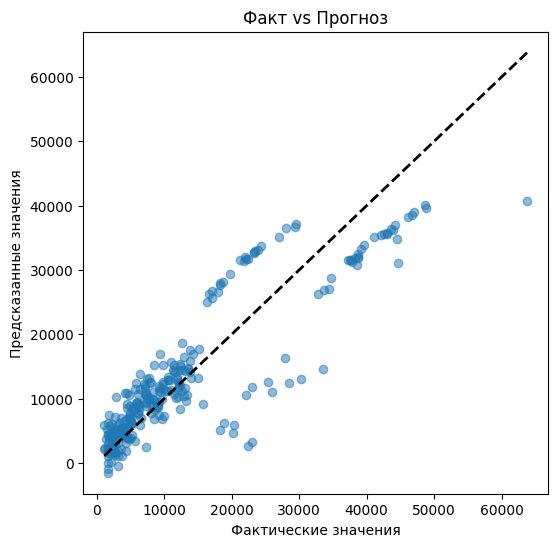

In [75]:
# Обучение
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_test)

# Оценка качества
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

# Визуализация результатов
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Факт vs Прогноз')
plt.show()

In [76]:
import joblib

# Сохраняем ВСЁ: ColumnTransformer + OneHot + Scaler + Model
joblib.dump(model, 'insurance_model_pipeline.joblib')

# Проверка загрузки
loaded_model = joblib.load('insurance_model_pipeline.joblib')
print(loaded_model.predict(pd.DataFrame([{'age': 30, 'bmi': 25, 'children': 0, 'sex': 'male', 'smoker': 'no', 'region': 'southwest'}])))

[3415.05947541]


In [77]:
# Создаем тестового клиента 
test_client = pd.DataFrame([{
    'age': 19,
    'sex': 'female',
    'bmi': 27.9,
    'children': 0,
    'smoker': 'yes',
    'region': 'southwest'
}])

# Предсказание
prediction = model.predict(test_client)[0]
print(f"Прогноз стоимости страховки: ${prediction:,.2f}")

Прогноз стоимости страховки: $25,094.40
